## Importações

In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 56.8 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- --------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Carregamento de X e y

In [4]:
caminho_x = Path("outputs/features/X.csv")
caminho_y = Path("outputs/features/y.csv")

df_X = pd.read_csv(caminho_x)
df_y = pd.read_csv(caminho_y)

print("X:", df_X.shape)
print("y:", df_y.shape)

df_X.head()

X: (200, 23)
y: (200, 3)


,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_v,media_r,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,arquivo,classe
0,86761.5,1431.844794,0.726920,0.531796,3.176218,7.553884,10.803499,12.064052,23.575179,15.987211,...,200.927679,198.129482,127.714961,62.540537,1.077351,0.873508,0.369939,0.974750,orange_0001.png,orange
1,39005.5,851.251869,0.755247,0.676425,3.195969,8.226834,11.572426,13.219955,-26.872955,18.988441,...,205.870485,200.452143,164.317398,92.513597,0.874133,0.842770,0.316409,0.951276,orange_0002.png,orange
2,98095.0,1339.851935,0.749389,0.686662,3.194271,8.069423,11.299280,13.194161,26.259716,-17.723484,...,227.913191,224.224214,153.099189,83.765053,0.814472,0.845971,0.373645,0.955187,orange_0003.png,orange
3,77772.5,1139.452878,0.817281,0.752737,3.194475,8.247984,11.539045,13.096108,25.425492,17.283714,...,204.600759,198.831884,134.447010,68.517355,0.868787,0.847221,0.378500,0.951358,orange_0004.png,orange
4,59190.5,1285.099627,0.646990,0.450390,3.193988,8.870036,11.496713,12.885858,-25.162749,-17.364138,...,213.664575,212.644910,113.399140,61.193185,1.356412,0.889333,0.481090,0.900675,orange_0005.png,orange


In [5]:
df_y.head()

,arquivo,classe,rotulo
0,orange_0001.png,orange,0
1,orange_0002.png,orange,0
2,orange_0003.png,orange,0
3,orange_0004.png,orange,0
4,orange_0005.png,orange,0


## Preparação dos dados

In [6]:
# Remove colunas que não são features numéricas
colunas_remover = ["arquivo", "classe"]

X = df_X.drop(columns=colunas_remover)

# Vetor de rótulos
y = df_y["rotulo"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

X.head()

Formato de X: (200, 21)
Formato de y: (200,)


,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_h,media_s,media_v,media_r,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation
0,86761.5,1431.844794,0.726920,0.531796,3.176218,7.553884,10.803499,12.064052,23.575179,15.987211,...,18.084060,175.325347,200.927679,198.129482,127.714961,62.540537,1.077351,0.873508,0.369939,0.974750
1,39005.5,851.251869,0.755247,0.676425,3.195969,8.226834,11.572426,13.219955,-26.872955,18.988441,...,23.619158,137.263240,205.870485,200.452143,164.317398,92.513597,0.874133,0.842770,0.316409,0.951276
2,98095.0,1339.851935,0.749389,0.686662,3.194271,8.069423,11.299280,13.194161,26.259716,-17.723484,...,17.045575,160.584502,227.913191,224.224214,153.099189,83.765053,0.814472,0.845971,0.373645,0.955187
3,77772.5,1139.452878,0.817281,0.752737,3.194475,8.247984,11.539045,13.096108,25.425492,17.283714,...,19.208548,166.832910,204.600759,198.831884,134.447010,68.517355,0.868787,0.847221,0.378500,0.951358
4,59190.5,1285.099627,0.646990,0.450390,3.193988,8.870036,11.496713,12.885858,-25.162749,-17.364138,...,12.686148,178.701495,213.664575,212.644910,113.399140,61.193185,1.356412,0.889333,0.481090,0.900675


In [7]:
y.value_counts()

rotulo
0    100
1    100
Name: count, dtype: int64

## Divisão treino, validação e teste

In [8]:
# Primeiro separa 20% para teste final
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Depois separa validação a partir do restante
# Resultado aproximado: 60% treino, 20% validação, 20% teste
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (120, 21) (120,)
Validação: (40, 21) (40,)
Teste: (40, 21) (40,)


In [9]:
print("Treino:")
print(y_train.value_counts())

print("\nValidação:")
print(y_val.value_counts())

print("\nTeste:")
print(y_test.value_counts())

Treino:
rotulo
0    60
1    60
Name: count, dtype: int64

Validação:
rotulo
1    20
0    20
Name: count, dtype: int64

Teste:
rotulo
0    20
1    20
Name: count, dtype: int64


## Função de avaliação

In [10]:
def avaliar_modelo(nome_modelo, modelo, X_avaliacao, y_avaliacao):
    y_pred = modelo.predict(X_avaliacao)

    acc = accuracy_score(y_avaliacao, y_pred)
    prec = precision_score(y_avaliacao, y_pred)
    rec = recall_score(y_avaliacao, y_pred)
    f1 = f1_score(y_avaliacao, y_pred)

    print(f"Modelo: {nome_modelo}")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nRelatório:")
    print(classification_report(
        y_avaliacao,
        y_pred,
        target_names=["orange", "rottenoranges"]
    ))

    return {
        "modelo": nome_modelo,
        "acuracia": acc,
        "precisao": prec,
        "recall": rec,
        "f1_score": f1
    }

## Modelo 1 — Random Forest

In [11]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

resultado_rf_val = avaliar_modelo(
    "Random Forest",
    modelo_rf,
    X_val,
    y_val
)

Modelo: Random Forest
Acurácia: 0.9000
Precisão: 0.9000
Recall: 0.9000
F1-score: 0.9000

Relatório:
               precision    recall  f1-score   support

       orange       0.90      0.90      0.90        20
rottenoranges       0.90      0.90      0.90        20

     accuracy                           0.90        40
    macro avg       0.90      0.90      0.90        40
 weighted avg       0.90      0.90      0.90        40



## Modelo 2 — SVM

In [12]:
modelo_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

modelo_svm.fit(X_train, y_train)

resultado_svm_val = avaliar_modelo(
    "SVM",
    modelo_svm,
    X_val,
    y_val
)

Modelo: SVM
Acurácia: 0.8500
Precisão: 0.8182
Recall: 0.9000
F1-score: 0.8571

Relatório:
               precision    recall  f1-score   support

       orange       0.89      0.80      0.84        20
rottenoranges       0.82      0.90      0.86        20

     accuracy                           0.85        40
    macro avg       0.85      0.85      0.85        40
 weighted avg       0.85      0.85      0.85        40



## Comparação dos modelos na validação

In [13]:
df_resultados_val = pd.DataFrame([
    resultado_rf_val,
    resultado_svm_val
])

df_resultados_val

,modelo,acuracia,precisao,recall,f1_score
0,Random Forest,0.90,0.900000,0.9,0.900000
1,SVM,0.85,0.818182,0.9,0.857143


In [14]:
melhor_modelo_nome = df_resultados_val.sort_values("f1_score", ascending=False).iloc[0]["modelo"]
melhor_modelo_nome

'Random Forest'

In [15]:
if melhor_modelo_nome == "Random Forest":
    melhor_modelo = modelo_rf
else:
    melhor_modelo = modelo_svm

resultado_teste = avaliar_modelo(
    melhor_modelo_nome,
    melhor_modelo,
    X_test,
    y_test
)

resultado_teste

Modelo: Random Forest
Acurácia: 0.9500
Precisão: 0.9500
Recall: 0.9500
F1-score: 0.9500

Relatório:
               precision    recall  f1-score   support

       orange       0.95      0.95      0.95        20
rottenoranges       0.95      0.95      0.95        20

     accuracy                           0.95        40
    macro avg       0.95      0.95      0.95        40
 weighted avg       0.95      0.95      0.95        40



{'modelo': 'Random Forest',
 'acuracia': 0.95,
 'precisao': 0.95,
 'recall': 0.95,
 'f1_score': 0.95}

## Matriz de confusão do melhor modelo

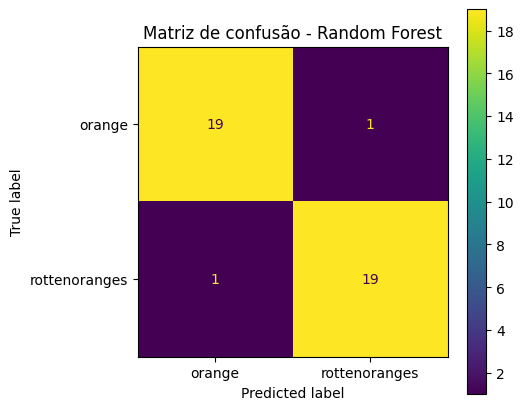

In [16]:
y_pred_test = melhor_modelo.predict(X_test)

matriz = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["orange", "rottenoranges"]
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format="d")
plt.title(f"Matriz de confusão - {melhor_modelo_nome}")
plt.show()

## Salvando resultados da classificação

In [17]:
pasta_saida = Path("outputs/classificacao")
pasta_saida.mkdir(parents=True, exist_ok=True)

df_resultados_val.to_csv(pasta_saida / "resultados_validacao.csv", index=False)

pd.DataFrame([resultado_teste]).to_csv(
    pasta_saida / "resultado_teste_melhor_modelo.csv",
    index=False
)

print("Resultados salvos em:", pasta_saida)

Resultados salvos em: outputs\classificacao


In [ ]:
#Foram treinados dois classificadores clássicos: Random Forest e SVM. Os modelos foram comparados no conjunto de validação usando acurácia,
#  precisão, recall e F1-score. O melhor modelo foi então avaliado no conjunto de teste, que ficou reservado para a avaliação final. A divisão
#  dos dados foi estratificada para manter a proporção entre laranjas saudáveis e podres nos conjuntos de treino, validação e teste.

In [18]:
df_resultados_val

,modelo,acuracia,precisao,recall,f1_score
0,Random Forest,0.90,0.900000,0.9,0.900000
1,SVM,0.85,0.818182,0.9,0.857143


In [19]:
resultado_teste

{'modelo': 'Random Forest',
 'acuracia': 0.95,
 'precisao': 0.95,
 'recall': 0.95,
 'f1_score': 0.95}

In [ ]:
#Na comparação dos classificadores, o Random Forest apresentou o melhor desempenho no conjunto de validação, com acurácia, precisão, recall 
# e F1-score iguais a 0.90. O SVM também obteve bom desempenho, mas ficou abaixo do Random Forest, principalmente em precisão e F1-score.

#Por esse motivo, o Random Forest foi escolhido como melhor modelo para avaliação final no conjunto de teste. No teste, o modelo alcançou 
# acurácia, precisão, recall e F1-score de 0.95, indicando boa capacidade de separar laranjas saudáveis e podres com base nas features manuais
#  extraídas.

In [20]:
y_pred_test = melhor_modelo.predict(X_test)

df_erros = pd.DataFrame({
    "indice": X_test.index,
    "arquivo": df_X.loc[X_test.index, "arquivo"].values,
    "classe_real": y_test.values,
    "classe_prevista": y_pred_test
})

df_erros = df_erros[df_erros["classe_real"] != df_erros["classe_prevista"]]

df_erros

,indice,arquivo,classe_real,classe_prevista
23,106,rottenoranges_0007.png,1,0
31,92,orange_0093.png,0,1


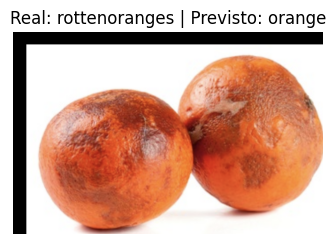

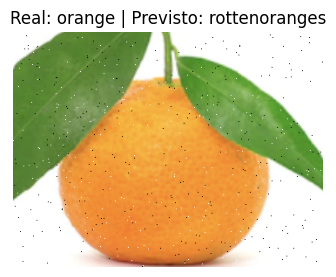

In [21]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

mapa_classes = {
    0: "orange",
    1: "rottenoranges"
}

df_erros["classe_real_nome"] = df_erros["classe_real"].map(mapa_classes)
df_erros["classe_prevista_nome"] = df_erros["classe_prevista"].map(mapa_classes)

for _, linha in df_erros.iterrows():
    classe_real = linha["classe_real_nome"]
    arquivo = linha["arquivo"]

    caminho_img = Path("dataset_trabalho") / classe_real / arquivo

    img_bgr = cv2.imread(str(caminho_img))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(
        f"Real: {linha['classe_real_nome']} | Previsto: {linha['classe_prevista_nome']}"
    )
    plt.axis("off")
    plt.show()

In [ ]:
#O melhor modelo errou 2 imagens no conjunto de teste. Uma laranja podre foi classificada como saudável, e uma laranja saudável foi classificada 
# como podre. O primeiro caso é mais crítico em uma aplicação real, pois representa deixar passar uma fruta fora do padrão. O segundo caso também
#  é indesejado, mas teria como consequência o descarte incorreto de uma fruta saudável. Esses erros podem estar relacionados a variações de 
# iluminação, manchas pouco evidentes, sombras ou limitações da segmentação.